<a href="https://colab.research.google.com/github/sudhasrinivas91/AI-Indoor--Air-Quality-Prediction/blob/main/IAQ_ML_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# STEP 1: INSTALL & IMPORT LIBRARIES
# ============================================================

!pip install -q xgboost openpyxl

# Data handling
import pandas as pd
import numpy as np
import zipfile
import os
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ============================================================
# STEP 2: UPLOAD YOUR DATASET ZIP
# ============================================================

from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
print(list(uploaded.keys()))

Saving dataset.zip to dataset.zip
Uploaded files:
['dataset.zip']


In [5]:
# ============================================================
# EXTRACT DATASET
# ============================================================

zip_file = "dataset.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("iaq_dataset")

print("Dataset extracted successfully!")

print(os.listdir("iaq_dataset"))

Dataset extracted successfully!
['IAQ Baqubah Teaching Hospital .csv']


In [6]:
# ============================================================
# STEP 3: LOAD DATASET
# ============================================================

csv_path = "iaq_dataset/IAQ Baqubah Teaching Hospital .csv"

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print()
print("Dataset Shape:", df.shape)

Dataset loaded successfully!

Dataset Shape: (523524, 12)


In [7]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['CO2', 'TVOC', 'PM10', 'PM2.5', 'eCO2', 'CO', 'Air Quality', 'LDR', 'O3', 'Temp', 'Hum', 'ts']

Data Types:
CO2            float64
TVOC           float64
PM10           float64
PM2.5          float64
eCO2           float64
CO             float64
Air Quality    float64
LDR            float64
O3             float64
Temp           float64
Hum            float64
ts              object
dtype: object

Missing Values:
CO2                 0
TVOC                0
PM10                0
PM2.5               0
eCO2           320365
CO                  0
Air Quality         0
LDR                 0
O3                  0
Temp                0
Hum                 0
ts                  0
dtype: int64


In [8]:
# Missing value percentage

missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

display(missing_table)

,Missing Values,Missing Percentage
CO2,0,0.000000
TVOC,0,0.000000
PM10,0,0.000000
PM2.5,0,0.000000
eCO2,320365,61.193947
CO,0,0.000000
Air Quality,0,0.000000
LDR,0,0.000000
O3,0,0.000000
Temp,0,0.000000


In [9]:
# ============================================================
# STEP 5: DATA PREPROCESSING
# ============================================================

data = df.copy()

# ------------------------------------------------------------
# 1. Check duplicates
# ------------------------------------------------------------

print("Duplicate rows before:", data.duplicated().sum())

data = data.drop_duplicates()

print("Duplicate rows after:", data.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


In [10]:
# Convert timestamp

data["ts"] = pd.to_datetime(
    data["ts"],
    errors="coerce"
)

print("Invalid timestamps:", data["ts"].isna().sum())

Invalid timestamps: 0


In [11]:
data = data.dropna(subset=["ts"])

print("Shape after timestamp cleaning:", data.shape)

Shape after timestamp cleaning: (523524, 12)


In [12]:
# Remove eCO2 because of excessive missing values

data = data.drop(columns=["eCO2"])

print("eCO2 removed.")
print(data.columns.tolist())

eCO2 removed.
['CO2', 'TVOC', 'PM10', 'PM2.5', 'CO', 'Air Quality', 'LDR', 'O3', 'Temp', 'Hum', 'ts']


In [13]:
print("Remaining missing values:")
print(data.isnull().sum())

Remaining missing values:
CO2            0
TVOC           0
PM10           0
PM2.5          0
CO             0
Air Quality    0
LDR            0
O3             0
Temp           0
Hum            0
ts             0
dtype: int64


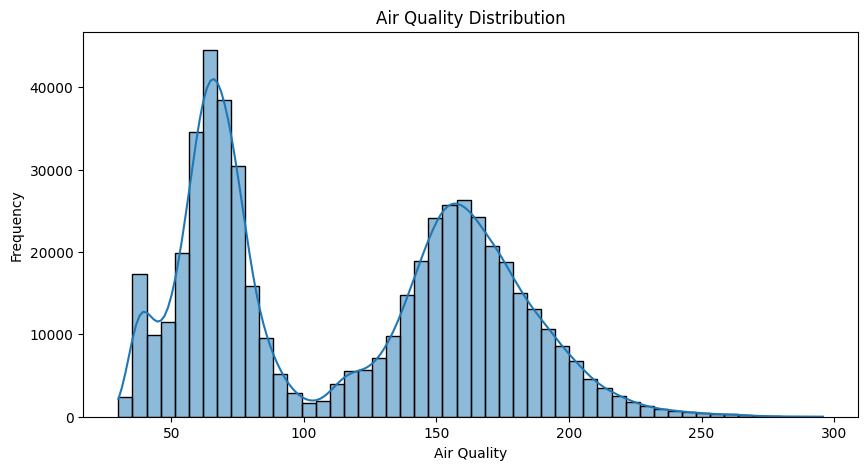

In [14]:
# ============================================================
# STEP 6: EXPLORATORY DATA ANALYSIS
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data["Air Quality"],
    bins=50,
    kde=True
)

plt.title("Air Quality Distribution")
plt.xlabel("Air Quality")
plt.ylabel("Frequency")

plt.show()

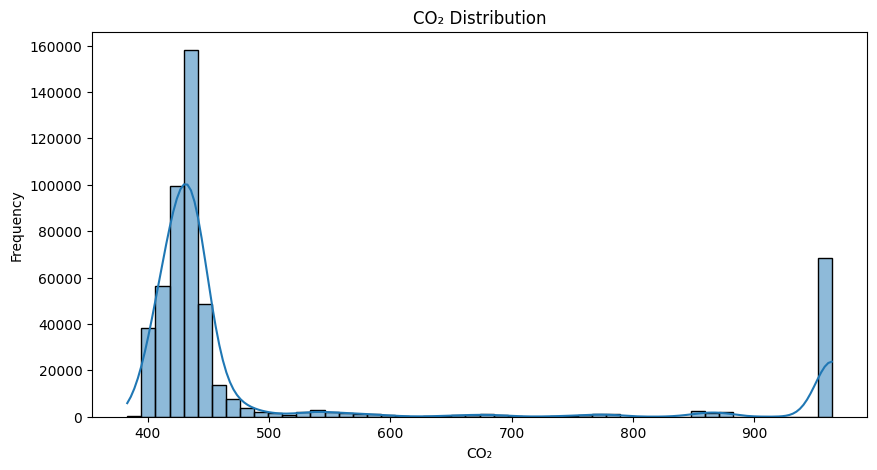

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data["CO2"],
    bins=50,
    kde=True
)

plt.title("CO₂ Distribution")
plt.xlabel("CO₂")
plt.ylabel("Frequency")

plt.show()

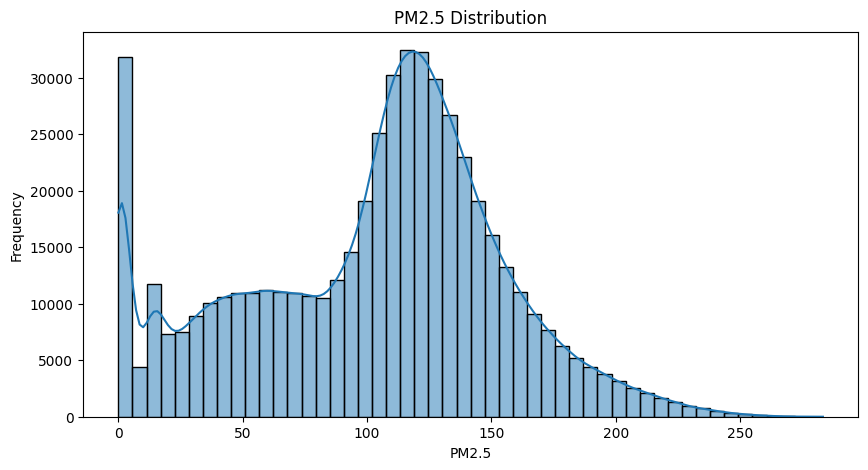

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data["PM2.5"],
    bins=50,
    kde=True
)

plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

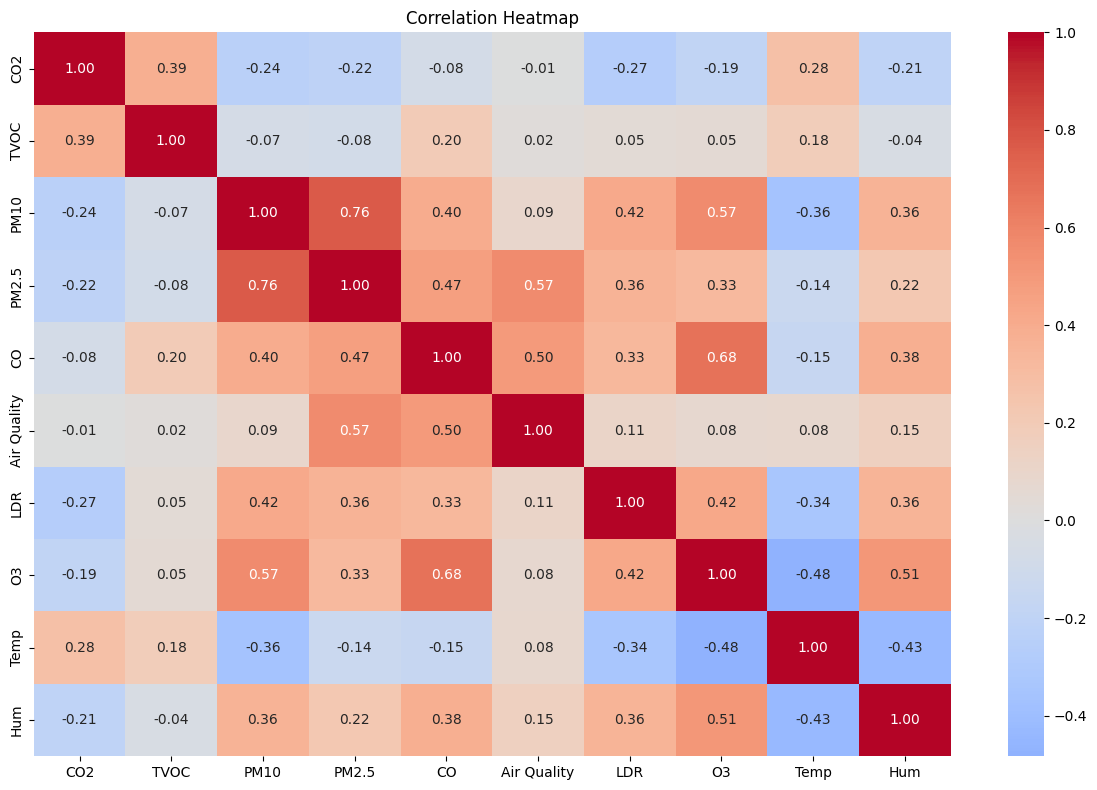

In [17]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

numeric_columns = data.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [18]:
# ============================================================
# STEP 8: FEATURE ENGINEERING
# ============================================================

data["hour"] = data["ts"].dt.hour
data["day"] = data["ts"].dt.day
data["month"] = data["ts"].dt.month
data["day_of_week"] = data["ts"].dt.dayofweek

print("Feature engineering completed!")

display(data.head())

Feature engineering completed!


,CO2,TVOC,PM10,PM2.5,CO,Air Quality,LDR,O3,Temp,Hum,ts,hour,day,month,day_of_week
0,425.000000,4.0,5.190,0.320000,357.0,42.000000,962.0,522.000000,26.300000,41.700000,2024-05-22 12:13:00,12,22,5,2
1,419.500000,26.5,5.240,0.260000,360.5,41.500000,962.0,521.500000,26.200000,41.650000,2024-05-22 12:14:00,12,22,5,2
2,420.666667,19.0,5.760,0.266667,360.0,41.333333,962.0,523.666667,26.133333,41.666667,2024-05-22 12:15:00,12,22,5,2
3,424.000000,15.5,5.765,0.292500,360.5,40.500000,962.0,524.750000,26.100000,41.650000,2024-05-22 12:16:00,12,22,5,2
4,419.200000,22.2,6.946,0.342000,357.2,40.400000,961.8,526.200000,25.920000,41.980000,2024-05-22 12:50:00,12,22,5,2


In [19]:
# ============================================================
# STEP 9: SELECT FEATURES AND TARGET
# ============================================================

features = [
    "CO2",
    "TVOC",
    "PM10",
    "PM2.5",
    "CO",
    "LDR",
    "O3",
    "Temp",
    "Hum",
    "hour",
    "day",
    "month",
    "day_of_week"
]

target = "Air Quality"

X = data[features]
y = data[target]

print("Number of features:", len(features))

print("\nFeatures:")
for feature in features:
    print("-", feature)

print("\nTarget:", target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of features: 13

Features:
- CO2
- TVOC
- PM10
- PM2.5
- CO
- LDR
- O3
- Temp
- Hum
- hour
- day
- month
- day_of_week

Target: Air Quality

X shape: (523524, 13)
y shape: (523524,)


In [20]:
# ============================================================
# STEP 10: TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 418819
Testing samples: 104705


In [21]:
# ============================================================
# STEP 11: LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

# Prediction
y_pred_lr = linear_model.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("LINEAR REGRESSION")
print("=================")
print("MAE :", round(mae_lr, 4))
print("RMSE:", round(rmse_lr, 4))
print("R²  :", round(r2_lr, 4))

LINEAR REGRESSION
MAE : 21.3685
RMSE: 27.6288
R²  : 0.7392


In [25]:
# ============================================================
# OPTIMIZED RANDOM FOREST FOR LARGE DATASET
# ============================================================

# Use a representative sample for Random Forest training
# This dramatically reduces training time while keeping
# the test set unchanged for evaluation.

RF_SAMPLE_SIZE = 100000

if len(X_train) > RF_SAMPLE_SIZE:
    X_rf_train, _, y_rf_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=RF_SAMPLE_SIZE,
        random_state=42
    )
else:
    X_rf_train = X_train
    y_rf_train = y_train

print("Original training samples:", len(X_train))
print("Random Forest training samples:", len(X_rf_train))

# Optimized Random Forest
rf_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
print("Please wait...")

rf_model.fit(
    X_rf_train,
    y_rf_train
)

print("Random Forest training completed!")

# Predict on the FULL test set
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("\nRANDOM FOREST RESULTS")
print("=====================")
print("MAE :", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R²  :", round(r2_rf, 4))

Original training samples: 418819
Random Forest training samples: 100000

Training Random Forest...
Please wait...
Random Forest training completed!

RANDOM FOREST RESULTS
MAE : 4.6499
RMSE: 7.0111
R²  : 0.9832


In [26]:
# ============================================================
# OPTIMIZED XGBOOST
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBOOST RESULTS")
print("================")
print("MAE :", round(mae_xgb, 4))
print("RMSE:", round(rmse_xgb, 4))
print("R²  :", round(r2_xgb, 4))

Training XGBoost...
XGBoost training completed!

XGBOOST RESULTS
MAE : 5.5351
RMSE: 8.3239
R²  : 0.9763


In [27]:
# ============================================================
# OPTIMIZED XGBOOST
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBOOST RESULTS")
print("================")
print("MAE :", round(mae_xgb, 4))
print("RMSE:", round(rmse_xgb, 4))
print("R²  :", round(r2_xgb, 4))

Training XGBoost...
XGBoost training completed!

XGBOOST RESULTS
MAE : 5.5351
RMSE: 8.3239
R²  : 0.9763


In [29]:
# ============================================================
# RECREATE MODEL COMPARISON RESULTS
# ============================================================

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],

    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],

    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

print("Model comparison table created successfully!")

display(results)

Model comparison table created successfully!


,Model,MAE,RMSE,R2 Score
0,Linear Regression,21.368468,27.628751,0.739212
1,Random Forest,4.649937,7.011057,0.983207
2,XGBoost,5.535051,8.323856,0.976329


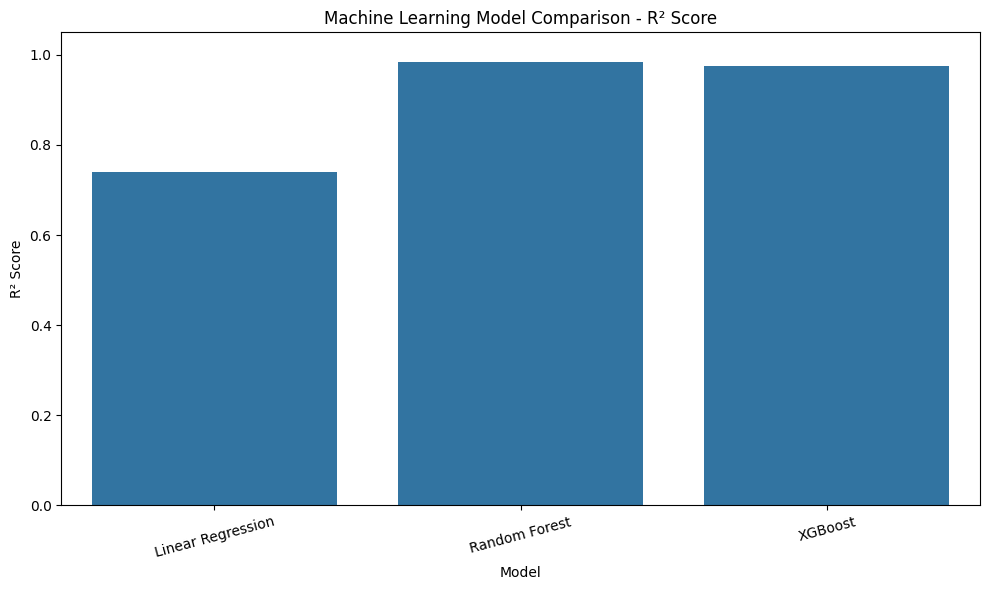

In [30]:
# ============================================================
# R² SCORE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Machine Learning Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.ylim(0, 1.05)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

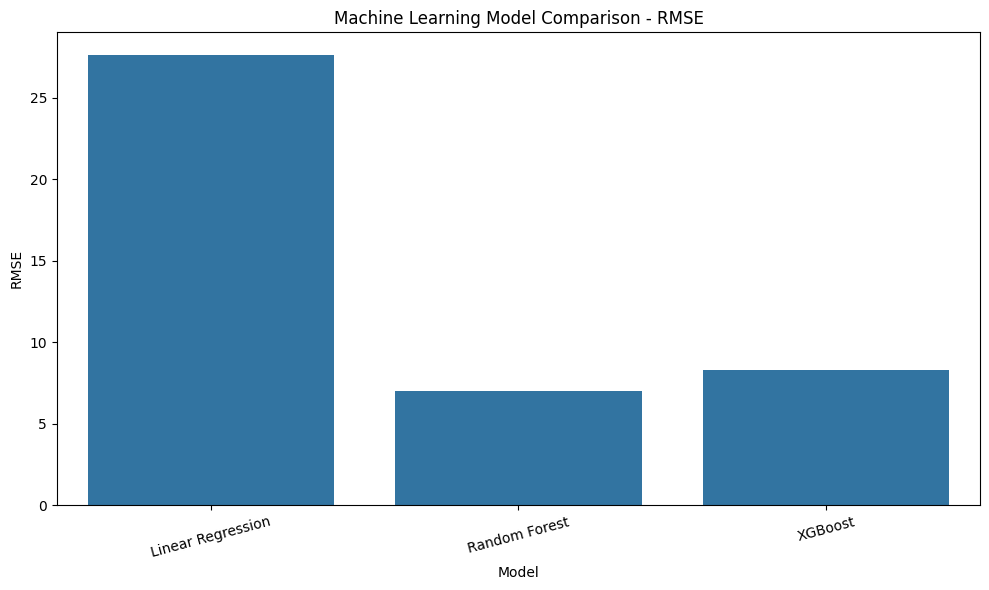

In [31]:
# ============================================================
# RMSE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("Machine Learning Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

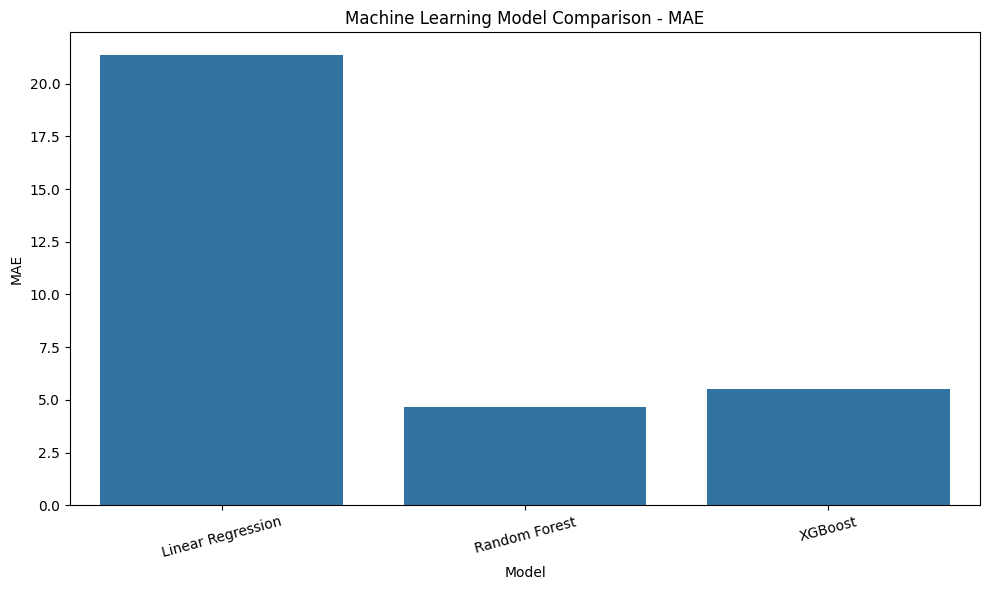

In [32]:
# ============================================================
# MAE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)

plt.title("Machine Learning Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()